# **Multivariate Regression**
### Student Scores:


## Goal

We want to predict a student’s exam score based on:

- x₁: Hours studied
- x₂: Hours slept

Model:
> score= w1*x1 + w2*x2 + b

## Step 1: Creating synthetic data

### explanation for below code
#### 1.
```
import pandas as pd
import numpy as np
```
- pandas → used for tables and easy data manipulation (DataFrame).
- numpy → used for numerical operations and generating random numbers.

#### 2.
``` 
np.random.seed(1)
```
- Sets the random seed so our random numbers are reproducible every time we run the code.

#### 3.
```

Hours_studied = np.random.randint(0, 12, 50) 
Hours_slept = np.random.randint(3, 9, 50)
```
- Hours_studied: generates 50 random integers between 0 and 11 (hours).
- Hours_slept: generates 50 random integers between 3 and 8 (hours).
- These are our input features for the regression model.

#### 4. 
```
Exam_score = (
    30 * Hours_studied +
    40 * Hours_slept +
    20 +                         # bias
    np.random.normal(0, 10, 50)  # noise
)
```
- Formula: score= 30*study + 40*sleep + 20 + noise
- 30 → contribution of hours studied.
- 40 → contribution of hours slept.
- 20 → base score (bias), ensures even 0 hours give some score.
- np.random.normal(0, 10, 50) → small random noise to make the data realistic, so predictions won’t be perfect.

#### 5.
```
df = pd.DataFrame({
    "Hours_studied": Hours_studied,
    "Hours_slept": Hours_slept,
    "Exam_score": Exam_score
})
```
- Combines features and target into a table.
- Each row = one student with inputs (Hours Studied, Hours Slept) and output (Exam Score).

In [8]:
import pandas as pd
import numpy as np

np.random.seed(1)

# Features
Hours_studied = np.random.randint(0, 12, 50) 
Hours_slept = np.random.randint(3, 9, 50)

# Target
Exam_score = (
    30 * Hours_studied +
    40 * Hours_slept +
    20 +                         # bias
    np.random.normal(0, 10, 50)  # noise
)

# DataFrame 
df = pd.DataFrame({
    "Hours_studied": Hours_studied,
    "Hours_slept": Hours_slept,
    "Exam Score": Exam_score
})

print(df.head())

   Hours_studied  Hours_slept  Exam Score
0              5            3  291.080866
1             11            4  520.152629
2              8            6  509.596368
3              9            7  568.726969
4             11            5  556.985542


## Step 2: Training the multivariate model
### Explanation for below code
#### 1.
```
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
```
- train_test_split → splits the data into training and testing sets
- LinearRegression → built-in regression model that finds weights automatically

#### 2.
```
# Features and target
X = df[["Hours_studied", "Hours_slept"]]
y = df["Exam Score"]

```
- X →  input features (Hours Studied, Hours Slept)
- y →  target variable (Exam Score)

#### 3.
```
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
```
- 80% of data → training
- 20% of data → testing
- Helps see how well the model generalizes

#### 4.
```
# Model
model = LinearRegression()
model.fit(X_train, y_train)
```
- Creates a linear regression model
- fit() → learns the weights (coefficients) and bias (intercept) from the training data

#### 5.
```
# Coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
```
- intercept_ → bias term (base score)
- coef_ → weights for each feature (Hours Studied, Hours Slept)
- Should be approximately [30, 40]  for our synthetic data, with a bias ≈ 20



In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features and target
X = df[["Hours_studied", "Hours_slept"]]
y = df["Exam Score"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 32.47675077340625
Coefficients: [29.24544323 38.4293754 ]


### Step 3: Making predictions

- y_pred → predicted exam scores for our test set
- y_all_pred → predicted exam scores for all students

In [12]:
# Predict on test data
y_pred = model.predict(X_test)

#  predict on all data
y_all_pred = model.predict(X)

### Step 4: Model Evaluation
- Check how close our predictions are to the actual exam scores.
- A simple metric is Mean Squared Error (MSE)
- Smaller MSE → predictions are closer to the actual scores
- Since our data has some noise, MSE won’t be 0, but it should be reasonably small

In [14]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error on test set:", mse)

# Square root of MSE
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Squared Error on test set: 152.34116289748033
Root Mean Squared Error (RMSE): 12.34265623346451


### → Evaluation interpretation: 
#### RMSE ≈ 12

This means:

> On average, the model’s predicted exam scores are off by about 12 points from the actual exam scores.
So if a student scored 80, the model might predict something around 68–92 (roughly +-12).

### Step 5. Visualization 

#### Code Explanation:

``` python 
import matplotlib.pyplot as plt
```
- Imports plotting library
- plt is just a shortcut name

----------------------------------------------
```python
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
```
What this does:
Creates a scatter plot (dots)
What each axis means:
- x-axis (y_test) → actual exam scores
- y-axis (y_pred) → predicted exam scores
- Each point = one student

Example:
- Actual = 80
- Predicted = 75
→ point plotted at (80, 75)
--------------------------------------------------------------------------------------------------------

```python
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Perfect Prediction')
```
This is VERY important
- Draws a straight red line
- This line represents: Predicted = Actual
- Predicted=Actual Meaning: If the model were perfect, all points would lie on this line
-------------------------------------------------------------------------------------------------------

```python
plt.xlabel("Actual Exam Scores")
```
- Labels the x-axis
-------------------------------------------------------------------------------------------------------

```python
plt.ylabel("Predicted Exam Scores")
```
- Labels the y-axis
--------------------------------------------------------------------------------------------------------

```python  
plt.title("Actual vs Predicted Exam Scores")
```
- Adds a title to the plot
---------------------------------------------------------------------------------------------------------

```python
plt.legend()
```
- Shows labels:
- Blue dots → predictions
- Red line → perfect prediction
---------------------------------------------------------------------------------------------------------------

```python
plt.show()
```
- Displays the plot
---------------------------------------------------------------------------------------------------------------  
#### How to Interpret the Plot
Case 1: Points near red line

→ Good predictions
→ Model is accurate

Case 2: Points far from red line

→ Bad predictions
→ High error

Where RMSE comes in ?

- RMSE ≈ average distance of points from the red line
- RMSE here ≈ 12
→ Most points should be about +-12 away from the red line
-------------------------------------------------------------------------------------------------------------------------------------------

Final Intuition

Think of it like this:
- Red line = perfect guesses
- Blue dots = your model’s guesses
- Distance from line = error

One simple check: When we look at the plot, ask:

“Are most points close to the red line or scattered far away?”

- If close → model is good
- If scattered → model is poor

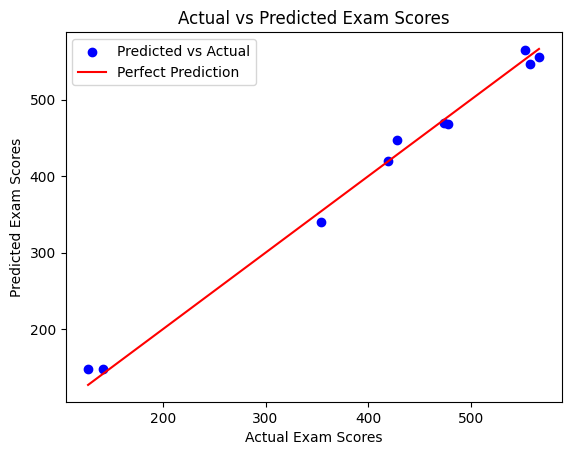

In [15]:
import matplotlib.pyplot as plt

# Scatter plot: actual vs predicted
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Perfect Prediction')
plt.xlabel("Actual Exam Scores")
plt.ylabel("Predicted Exam Scores")
plt.title("Actual vs Predicted Exam Scores")
plt.legend()
plt.show()

#### Interpretation
- Most points lie close to the perfect prediction line, indicating good model performance.
- RMSE ≈ 12 means predictions differ from actual values by about 12 marks on average.